#  Gravitational Wave Data Analysis tutorial #2

This notebook gives an introductions to Bayesian inference and parameter inference for gravitational wave signals from compact binary coalescences (CBCs), with an application to recover the (simplified) parameters of GW150914 in real data.

We refer to the lectures and tutorials available at the GWOSC: [Gravitational-Wave Open Science Center (GWOSC)](https://www.gw-openscience.org).

Another useful workshop dealing with the simulation and analysis of LISA data is available here: [LISA Data Generation and Analysis Workshop](https://indico.in2p3.fr/event/33255/overview)

For a good pedagogical resource on MCMC, see [[arXiv:1710.06068]](https://arxiv.org/abs/1710.06068) 

We will use the powerful MCMC, ensemble-sampler [Eryn](https://github.com/mikekatz04/Eryn) that allow for parallel tempering and transdimensionality.

We will focus on MCMC techniques, but Nested Sampling plays an important role in GW astronomy.

Bilby is used in production in LVK:
See also Nessai:
    
[Click this link to view this tutorial in Google Colaboratory](https://colab.research.google.com/github/SylvainMarsat/gwda_tutorial/blob/main/tutorial_2.ipynb)

Author date

When running in Google Colab, uncomment and run the cell to install latex for matplotlib:

## Install

When running in Google Colab, uncomment and run the cell to install required packages:

In [ ]:
#! pip install numpy scipy h5py matplotlib ipython jupyterlab tqdm lalsuite gwpy eryn corner bilby

When running in Google Colab, uncomment and run the cell to download the required data:

## Imports

In [33]:
import os, sys
import h5py, json
import copy
import numpy as np
import scipy
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from tqdm import tqdm as tqdm

import astropy.units as u

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio") # to silence a warning
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import lal
import lalsimulation
import lalsimulation.gwsignal.core.waveform as wfm
from lalsimulation.gwsignal import gwsignal_get_waveform_generator

import gwpy

# import ptemcee
import eryn
import corner
import bilby

In [2]:
%matplotlib inline

## Definitions

In [97]:
colors = ["#4C72B0", "#C44E52", "#CCB974", "#55A868", "#8172B2", "#64B5CD", '#FFA500', '#A0522D']

rc_params = {'backend': 'ps',
            'axes.unicode_minus':False,
            'axes.grid':True,
            'lines.linewidth':1.,
            'grid.linestyle':':',
            'grid.linewidth':1.,
            'hist.bins':50,
            'axes.labelsize':16,
            'axes.titlesize':16,
            'xtick.labelsize':16,
            'ytick.labelsize':16,
            'legend.fontsize':16,
            'figure.dpi':100}
plt.rcParams.update(rc_params)

In [98]:
# Definitions for the windowing function -- function for vectorial argument
# In order to avoid overflows in the exponentials, we set the boundaries (di, df) so that anything below 10^-20 is considered zero
def window_planck(x, xi, xf, deltaxi, deltaxf):
    di = deltaxi/(20*np.log(10))
    df = deltaxf/(20*np.log(10))
    w = np.zeros(len(x), dtype=float)
    #
    mask = (x <= xi + di) | (x >= xf - df)
    w[mask] = 0.
    #
    mask = (xi + di < x) & (x < xi + deltaxi - di)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(deltaxi/(xm - xi) + deltaxi/(xm - (xi + deltaxi))))
    #
    mask = (xi + deltaxi - di <= x) & (x <= xf - deltaxf + df)
    w[mask] = 1.
    #
    mask = (xf - deltaxf + df < x) & (x < xf - df)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(-(deltaxf/(xm - (xf - deltaxf))) - deltaxf/(xm - xf)))
    #
    return w

In [99]:
def fft_positivef(times, data):
    n = len(times)
    deltat = times[1] - times[0]
    deltaf = 1./(n*deltat)
    # Fast Fourier Transform
    freqs = deltaf*np.arange(n)
    # BEWARE: due to the different convention for the sign of Fourier frequencies, we have to reverse the FFT output
    # Beware also that the FFT treats effectively the initial time as 0
    # BEWARE: in the reversion of the numpy-convention FFT output, we have to set aside the 0-frequency term
    data_fd = deltat * np.fft.fft(data)
    # Discarding information on negative frequencies - if real timeseries in input, no information loss as the deleted values are the conjugate
    data_fd = data_fd[:n//2+1]
    freqs = freqs[:n//2+1]
    # Coming back to the initial times
    tshift = times[0]
    fac_timeshift = np.exp(1j*2*np.pi*freqs*tshift)
    data_fd = data_fd * fac_timeshift
    return freqs, data_fd

In [100]:
def ifft_positivef(freqs, data, tstart=0., real=False):
    # Assumes n = N/2+1, with N length of data
    n = len(freqs)
    deltaf = freqs[1] - freqs[0]
    # Zero-pad to next power of 2, then 0-pad by factor 2 for the negative frequencies
    N = 2*(n - 1)
    # N_pad = 2**(int(np.ceil(np.log(N) / np.log(2))) + 1)
    freqs_pad = deltaf * np.arange(N)
    data_pad = np.zeros(N, dtype=data.dtype)
    data_pad[:n] = data
    # If data is FFT of real data, complete implicit f<0 values in the second half of the vector
    if real:
        data_pad[n:] = np.conj(data[1:n-1][::-1])
    # Factor to restore times
    fac_timeshift = np.exp(-1j*2*np.pi*freqs_pad*tstart)
    # Inverse FFT
    deltat = 1./(N*deltaf)
    data_td = 1./deltat * np.fft.ifft(fac_timeshift * data_pad)
    if real:
        data_td = np.real(data_td)
    # Rebuild times
    times = tstart + deltat * np.arange(N)
    return times, data_td

# Part I: basics of Bayesian inference with Gaussian distributions 

In Bayesian inference, we want to produce samples in $\theta$ from a posterior $p(\theta | d)$, given by Bayes' theorem
$$ p(\theta | d) = \frac{p(d | \theta) p(\theta)}{p(d)} $$
with $p(d | \theta)$ the likelihood, $p(\theta)$ the prior, and $p(d)= \int d\theta \, p(d | \theta) p(\theta)$ the evidence.

In this first part we will illustrate a simple sampling technique, Metropolis-Hastings MCMC, show its limitation and show how they can be alleviated by parallel tempering.

In MH-MCMC, one chooses freely a proposal $q(x,y)$, probability of jumping from $x$ to $y$. The proposed jump is then accepted with probability
$$\alpha(x,y) = \mathrm{min} \left( 1, \frac{q(y,x)}{q(x,y)} \frac{p(y)}{p(x)} \right)$$
where $p(x)$ is the target pdf we want to sample from.

## Definitions

These definitions are for the pdf of a multivariate Gaussian (we only use 1D Gaussians here).

In [3]:
def normal_pdf(x, mean, invcov, detcov=None, normalized=True):
    mean = np.atleast_1d(mean)
    invcov = np.atleast_2d(invcov)
    x = np.atleast_2d(x)
    n = mean.shape[0]
    u = (x.T - mean).T
    pdf = np.exp(-1./2 * np.sum(u * np.dot(invcov, u), axis=0))
    if normalized:
        if detcov is None:
            detcov = 1./np.linalg.det(invcov) 
        pdf /= (2*np.pi)**(n/2.) * np.sqrt(detcov)
    return pdf

def normal_logpdf(x, mean, invcov, detcov=None, normalized=True):
    mean = np.atleast_1d(mean)
    invcov = np.atleast_2d(invcov)
    x = np.atleast_2d(x)
    n = mean.shape[0]
    u = (x.T - mean).T
    logpdf = -1./2 * np.sum(u * np.dot(invcov, u), axis=0)
    if normalized:
        if detcov is None:
            detcov = 1./np.linalg.det(invcov) 
        logpdf -= n/2. * np.log(2*np.pi) + 1./2 * np.log(detcov)
    return logpdf

An example code for MH-MCMC -- illustrative only, not optimized in any way !

In [359]:
class normal_proposal:
    '''
    Simple class for a proposal, for drawing a new point and also evaluating the prob. density of the jump
    '''
    def __init__(self, cov):
        self.n_dim = cov.shape[0]
        self.mean = np.zeros(n_dim, dtype=float)
        self.cov = cov
        self.invcov = np.linalg.inv(cov)
        self.detcov = np.linalg.det(cov)
    def draw(self, x):
        # NOTE: this is inefficient, we should diagonalize cov once and for all, here it is done at each step
        return x + np.random.multivariate_normal(self.mean, self.cov)
    def density(self, x, y):
        u = y - x
        return 1./(2*np.pi)**(self.n_dim/2.)/np.sqrt(self.detcov) * np.exp(-1./2 * np.linalg.multi_dot([u, self.invcov, u]))

class MHMCMC:
    '''
    Simple class for a single-walker MH-MCMC sampler
    '''
    def __init__(self, n_dim, x_ini=None, loglikelihood=None, logprior=None, proposal=None, seed=None, jump=None, jump_prob=0.):
        self.n_dim = n_dim
        self.loglikelihood = loglikelihood
        self.logprior = logprior
        self.proposal = proposal
        self.x = None
        self.lnL = None
        self.lnprior = None
        self.lnpost = None
        self.jump = jump
        self.jump_prob = jump_prob
        self.seed = seed
        self.x = None
        if x_ini is None:
            self.x_ini = np.zeros(n_dim, dtype=float)
        else:
            self.x_ini = x_ini
    
    def step(self, x, lnL, lnprior, lnpost, i, jump=None, jump_prob=0.):
        # y current point, z new point
        y = x[i-1]
        lnpost_y = lnpost[i-1]
        # Branch between the normal proposal and the jump proposal
        v = np.random.uniform()
        if v >= jump_prob:
            z = self.proposal.draw(y)
            q_yz = self.proposal.density(y, z)
            q_zy = self.proposal.density(z, y)
        else:
            direction = 2*(np.random.randint(0, 2)-1./2) # This is -1 or 1, coin flip
            z = y + direction * jump # Jump in either direction
            q_yz = 1.
            q_zy = 1.
        lnlike_z = self.loglikelihood(z)
        lnprior_z = self.logprior(z)
        lnpost_z = lnlike_z + lnprior_z
        alpha_yz = np.fmin(1., np.exp(lnpost_z - lnpost_y) * q_zy / q_yz)
        u = np.random.uniform()
        accept = (u < alpha_yz)
        if accept:
            x[i] = z
            lnL[i] = lnlike_z
            lnprior[i] = lnprior_z
            lnpost[i] = lnpost_z
        else:
            x[i] = y
            lnL[i] = lnL[i-1]
            lnprior[i] = lnprior[i-1]
            lnpost[i] = lnpost[i-1]
        return accept
        
    def run(self, n_iter, monitor=True):
        self.x = np.zeros((n_iter, n_dim), dtype=float)
        self.lnL = np.zeros(n_iter, dtype=float)
        self.lnprior = np.zeros(n_iter, dtype=float)
        self.lnpost = np.zeros(n_iter, dtype=float)
        self.x[0] = self.x_ini.copy()
        self.lnL[0] = self.loglikelihood(self.x[0])
        self.lnprior[0] = self.logprior(self.x[0])
        self.lnpost[0] = self.lnL[0] + self.lnprior[0]
        if self.seed is not None:
            np.random.seed(self.seed)
        for i in tqdm(range(1, n_iter), disable=(not monitor)):
            accept = self.step(self.x, self.lnL, self.lnprior, self.lnpost, i, jump=self.jump, jump_prob=self.jump_prob)

## MH-MCMC simple example: 1D Gaussian

Here we do the simplest possible example in sampling: the 1D Gaussian.

In [340]:
n_dim = 1

prior_range = [[-10., 10.]]

# Simple Gaussian as likelihood
mean_val = 0.
mean = np.array([0])
cov = np.array([[1.]])
invcov = np.array([[1.]])

def loglikelihood(x):
    return normal_logpdf(x, mean, invcov, normalized=False)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.infty
    return 1.

# Arbitrary covariance for the proposal, 1-sigma step of 0.5
cov_prop = np.array([[0.25]])
proposal = normal_proposal(cov_prop)

# Starting point of the chain
x_ini = np.array([0.])

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

In [341]:
sampler.run(10000)

100%|███████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 5857.62it/s]


In [342]:
sampler.x.shape

(10000, 1)

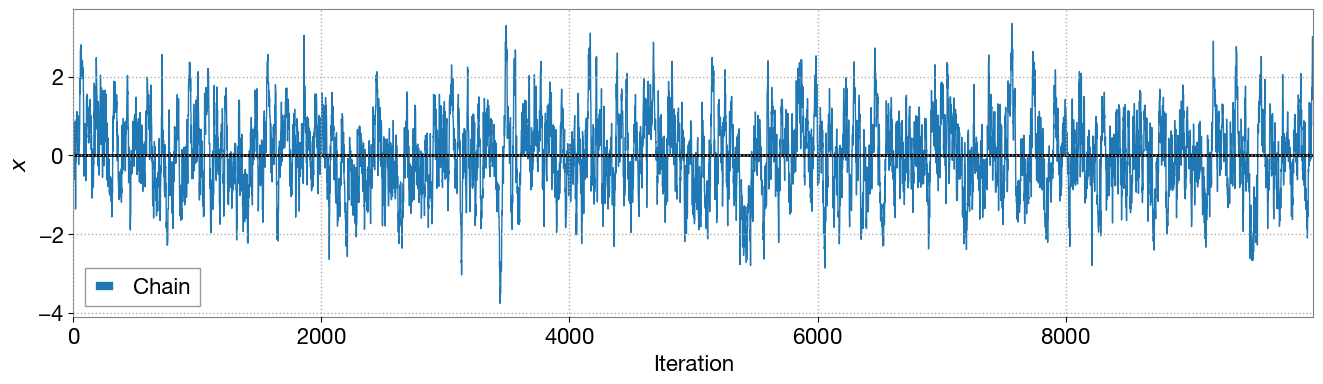

In [343]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(sampler.x.flatten(), label='Chain')

ax.set_xlim(0, sampler.x.shape[0]-1)
ax.axhline(mean_val, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

ax.legend()

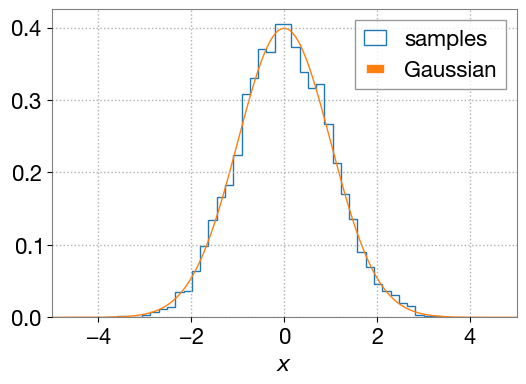

In [344]:
x_arr = np.linspace(-5., 5., 1000)
target_p = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    target_p[i] = normal_pdf(x_arr[i], mean, invcov, normalized=True)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(sampler.x.flatten(), histtype='step', density=True, bins=40, label='samples');
ax.plot(x_arr, target_p, label='Gaussian')
ax.set_xlim(-5., 5.)
ax.set_xlabel(r'$x$')
ax.legend()

## Simulating noisy observations

Here, we give a glimpse on what happens for repeated simulated noisy observations, with a frequentist pont of view.

We make $N$ draws of noise, simulating data as data=signal+noise (here the 'signal' is just the value 0). The noise is drawn according to our likelihood function, which is just the Gaussian with sigma=1. Next, we simulate PE to get posterior samples. NOTE: in principle, we should draw the signal from the same prior as used in PE -- to avoid introducing prior bounds, we set the signal to 0 always. 

This allows us to build a PP-plot: for each posterior, we get the confidence level (p-value) of the true signal parameter in that posterior; and we plot the cumulative distribution of this p-value. This must follow the unit diagonal, with some scatter that we can estimate based on the number of simulations.

In [345]:
def draw_noise():
    return np.random.normal(mean, cov)[0,0]
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.infty
    return 1.

In [295]:
n_noise_real = 100

np.random.seed(1)

# NOTE: we do not draw the signal according to the prior - in principle we should
signal = np.zeros(n_noise_real, dtype=float)
noise = np.zeros(n_noise_real, dtype=float)
for i in range(n_noise_real):
#     signal[i] = np.random.uniform(low=prior_range[0][0], high=prior_range[0][1])
    signal[i] = mean_val
    noise[i] = draw_noise()

In [296]:
n_iter = 4000
burn_in = 2000

samples_noise_real = np.zeros((n_noise_real,n_iter-burn_in), dtype=float)
for i in tqdm(range(n_noise_real)):
    data = signal[i] + noise[i]
    def loglikelihood(x):
        return normal_logpdf(x, np.array([data]), invcov, normalized=False)
    sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)
    sampler.run(n_iter, monitor=False)
    samples_noise_real[i] = sampler.x.flatten()[burn_in:]

100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:59<00:00,  1.69it/s]


Text(0.5, 0, '$x$')

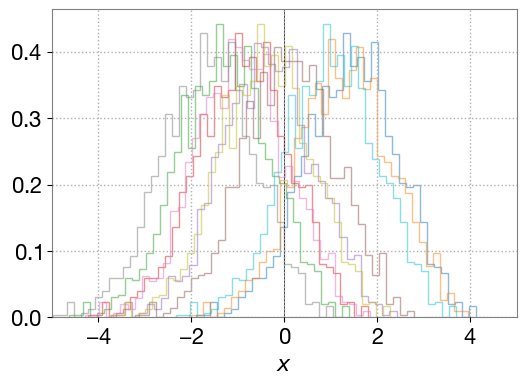

In [297]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
for i in range(n_noise_real)[::10]:
    ax.hist(samples_noise_real[i], histtype='step', density=True, alpha=0.5, bins=40);#, label=r'$n_{\rm dim}=' + str(n_dim) + '$', color=plotpalette[i])
ax.axvline(0., c='k', lw=0.5)
ax.set_xlim(-5., 5.)
ax.set_xlabel(r'$x$')

In [298]:
def pvalue_from_post(s, samples):
    m = np.median(samples)
    if m <= s:
        return 2 * np.sum(s < samples) / len(samples)
    else:
        return 2 * np.sum(samples < s) / len(samples)

# Theoretical interval, at the level prob
# The cumulative fraction, for each p-level p, follows ~B(N*p + 1, N - N*p + 1) (B binomial law)
def pvalue_interval(p, n, prob, size=10000):
    beta_vals = np.random.beta(n*p + 1, n - n*p + 1, size=size)
    return np.quantile(beta_vals, np.array([(1-prob)/2., (1+prob)/2.]))

In [299]:
pvalues = np.zeros(n_noise_real, dtype=float)
for i in range(n_noise_real):
    pvalues[i] = pvalue_from_post(signal[i], samples_noise_real[i])

Text(0, 0.5, 'Cumulative fraction of events')

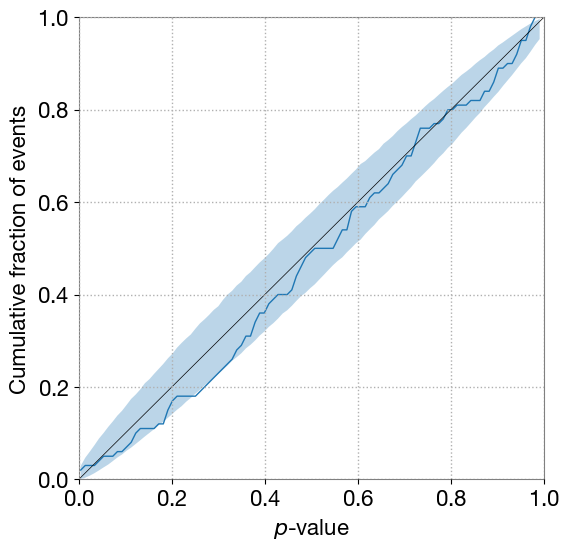

In [300]:
prob = 0.9

H,X = np.histogram(pvalues, bins=100, density=True)
p_lim_low = np.zeros_like(X)
p_lim_high = np.zeros_like(X)
for iX in range(len(X)):
    p = iX / len(X)
    p_lim_low[iX], p_lim_high[iX] = pvalue_interval(p, n_noise_real, prob)

fig, ax = plt.subplots(1,1, figsize=[6,6])
ax.plot(X[:-1], np.cumsum(H) / np.sum(H))
ax.fill_between(X, p_lim_low, p_lim_high, alpha=0.3)
# ax.plot(X, p_lim_low)
# ax.plot(X, p_lim_high)
ax.plot(np.array([0., 1.]), np.array([0., 1.]), c='k', lw=0.5)
ax.set_xlim(0., 1.)
ax.set_ylim(0., 1.)
ax.set_xlabel(r'$p$-value')
ax.set_ylabel(r'Cumulative fraction of events')

## Failing to mix well between modes

We now introduce some mild bimodality in the target likelihood, with two modes that are still connected. We keep the same Gaussian proposal.
- run the sampler and interpret the result

In [346]:
n_dim = 1

prior_range = [[-10., 10.]]

mean_val_1 = -5.
mean_val_2 = 5.
w_1 = 0.2
w_2 = 0.8

mean_1 = mean_val_1 + np.zeros(n_dim, dtype=float)
mean_2 = mean_val_2 + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

cov = np.array([[4.]])
invcov = np.array([[0.25]])

def loglikelihood(x):
    p_1 = normal_pdf(x, mean_1, invcov, normalized=False)
    p_2 = normal_pdf(x, mean_2, invcov, normalized=False)
    return np.log(w_1*p_1 + w_2*p_2)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.inf
    return 1.

# Arbitrary covariance for the proposal, 1-sigma step of 0.5
cov_prop = np.array([[0.25]])
proposal = normal_proposal(cov_prop)

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

Text(0, 0.5, '$\\mathcal{L}$')

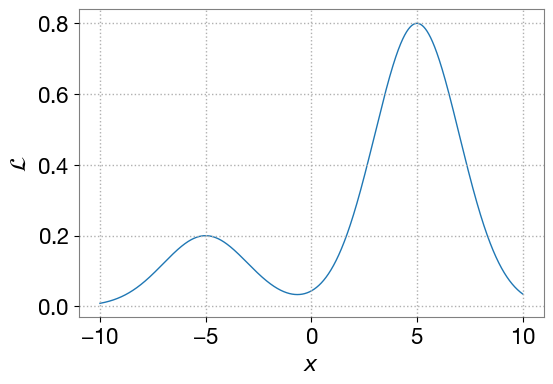

In [347]:
x_arr = np.linspace(-10., 10., 10000)
lnL_arr = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    lnL_arr[i] = loglikelihood(x_arr[i])
L_arr = np.exp(lnL_arr)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(x_arr, L_arr)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\mathcal{L}$')

## Failing to even find other modes

We now introduce some stronger bimodality in the target likelihood, with two modes that are disconnected, with a valley of low probability in-between. We keep the same Gaussian proposal.
- run the sampler and interpret the result

In [351]:
n_dim = 1

prior_range = [[-10., 10.]]

mean_val_1 = -5.
mean_val_2 = 5.
w_1 = 0.2
w_2 = 0.8

mean_1 = mean_val_1 + np.zeros(n_dim, dtype=float)
mean_2 = mean_val_2 + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

cov = np.array([[0.25]])
invcov = np.array([[4.]])

def loglikelihood(x):
    p_1 = normal_pdf(x, mean_1, invcov, normalized=False)
    p_2 = normal_pdf(x, mean_2, invcov, normalized=False)
    return np.log(w_1*p_1 + w_2*p_2)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.inf
    return 1.

# Arbitrary covariance for the proposal, 1-sigma step of 0.5
cov_prop = np.array([[0.25]])
proposal = normal_proposal(cov_prop)

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1)

## Trying to add a jump proposal

To address known multimodality, a powerful method in MCMC is to branch between different proposals, adding a jump proposal that will allow for non-local jumps in parameter space. This only works if we know the multimodality in advance !
- choose a jump
- run the sampler and interpret the result

In [ ]:
# When initializing the sampler class, we can pass 
# sampler = MHMCMC(..., jump=jump, jump_prob=jump_prob)
# jump is the size of the jump, jump_prob is the branching probability for this new proposal (how frequently we try to jump)

In [360]:
n_dim = 1

prior_range = [[-10., 10.]]

mean_val_1 = -5.
mean_val_2 = 5.
w_1 = 0.2
w_2 = 0.8

mean_1 = mean_val_1 + np.zeros(n_dim, dtype=float)
mean_2 = mean_val_2 + np.zeros(n_dim, dtype=float)
x_ini = np.zeros(n_dim) + mean_val

cov = np.array([[0.25]])
invcov = np.array([[4.]])

def loglikelihood(x):
    p_1 = normal_pdf(x, mean_1, invcov, normalized=False)
    p_2 = normal_pdf(x, mean_2, invcov, normalized=False)
    return np.log(w_1*p_1 + w_2*p_2)
def logprior(x):
    for i in range(n_dim):
        if (x[i] < prior_range[i][0] or prior_range[i][1] < x[i]):
            return -np.inf
    return 1.

# Arbitrary covariance for the proposal, 1-sigma step of 0.5
cov_prop = np.array([[0.25]])
proposal = normal_proposal(cov_prop)

jump = 10.
jump_prob = 0.5

sampler = MHMCMC(1, x_ini=x_ini, loglikelihood=loglikelihood, logprior=logprior, proposal=proposal, seed=1, jump=jump, jump_prob=jump_prob)

Text(0, 0.5, '$\\mathcal{L}$')

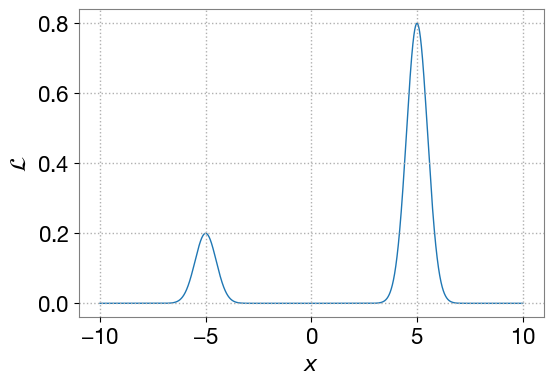

In [361]:
x_arr = np.linspace(-10., 10., 10000)
lnL_arr = np.zeros_like(x_arr)
for i in range(x_arr.shape[0]):
    lnL_arr[i] = loglikelihood(x_arr[i])
L_arr = np.exp(lnL_arr)

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.plot(x_arr, L_arr)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\mathcal{L}$')

In [362]:
sampler.run(10000)

100%|███████████████████████████████████████████████████████████████████████████████| 9999/9999 [00:01<00:00, 8187.21it/s]


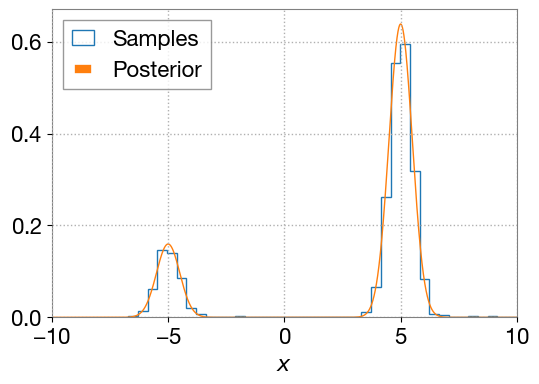

In [363]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(sampler.x.flatten(), histtype='step', density=True, bins=40, label='Samples')
ax.plot(x_arr, L_arr / np.sum(np.diff(x_arr) * L_arr[:-1]), label='Posterior')
ax.set_xlim(-10., 10.)
ax.set_xlabel(r'$x$')
ax.legend()

Text(0, 0.5, '$x$')

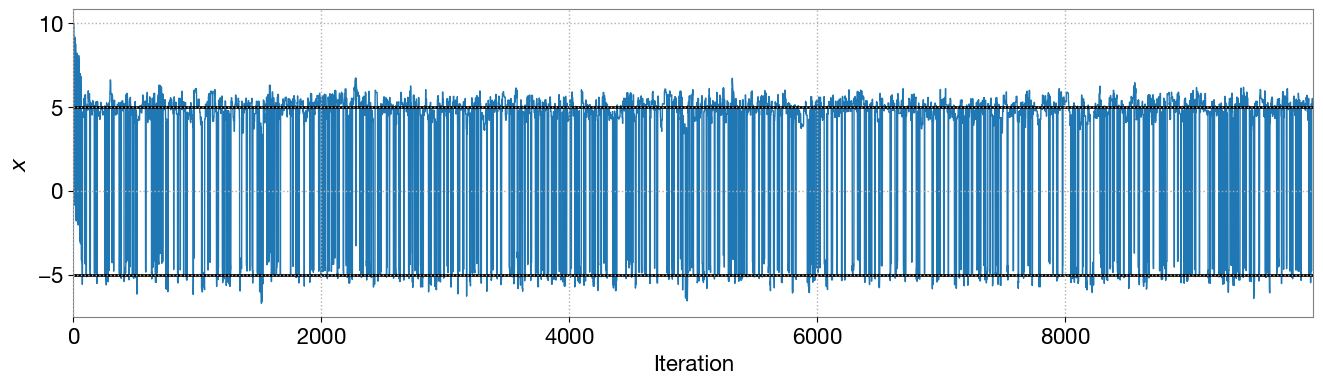

In [364]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(sampler.x.flatten())
ax.set_xlim(0, sampler.x.shape[0]-1)
ax.axhline(mean_val_1, c='k', lw=2.)
ax.axhline(mean_val_2, c='k', lw=2.)
ax.set_xlabel(r'Iteration')
ax.set_ylabel(r'$x$')

## Parellel tempering to the rescue: Eryn

We will use the MCMC, ensemble-sampler [Eryn](https://github.com/mikekatz04/Eryn) that allows for parallel tempering.

In [47]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds

In [48]:
# Params: M, q, A, Deltat, alpha
prior_range = np.array([
    [-10., 10.]])

In [49]:
# set prior limits
ndim = 1
priors_in = {i: uniform_dist(prior_range[i][0], prior_range[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)

In [61]:
ndim = 1
nwalkers = 32
ntemps = 5
Tmax = 50
nsteps = 1000
burn = int(nsteps/2)

# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps, Tmax=Tmax)

# Starting positions
# randomize throughout prior
coords = priors.rvs(size=(ntemps, nwalkers,))

# initialize sampler
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    loglikelihood,
    priors,
    args=[],
    tempering_kwargs=tempering_kwargs
)

In [59]:
coords.shape

(5, 32, 1)

In [62]:
out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=1)

100%|████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 173.83it/s]


In [63]:
# Formats:
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim). -- nleaves_max=1, ignore here
# log_likelihoods: (nsteps, ntemps, nwalkers).

samples = ensemble.get_chain()['model_0']
log_likelihoods = ensemble.get_log_like()
samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 1), (1000, 5, 32))

In [64]:
temp = 0

samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

In [65]:
samples_flat.shape, lnlike_flat.shape

((16000, 1), (16000,))

- Plot the distribution of lnL values in the output chains
- Plot the chain trajectory
- Plot the samples histogram for the different temperature chains

# Part II: example parameter estimation for GW150914

## Setup: downloading strain data, evaluating PSD, data in the Fourier domain

Here we simply repeat setup steps from `tutorial_1`

In [207]:
from gwosc import datasets
from gwosc.datasets import find_datasets
from gwosc.datasets import event_gps

from gwpy.timeseries import TimeSeries

In [208]:
t_gps = event_gps('GW150914')
print(t_gps)

1126259462.4


In [209]:
# H1_data = TimeSeries.read('./data/GW150914/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")
# L1_data = TimeSeries.read('./data/GW150914/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")

In [210]:
segment = (int(t_gps) - 16, int(t_gps) + 16)
H1_data = TimeSeries.fetch_open_data('H1', *segment, verbose=True, cache=True)
L1_data = TimeSeries.fetch_open_data('L1', *segment, verbose=True, cache=True)

Fetched 1 URLs from gwosc.org for [1126259446 .. 1126259478))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1126259446 .. 1126259478))
Reading data... [Done]


In [211]:
times = np.asarray(H1_data.times).copy()
# New origin of times: middle of our data interval
t_center = times[len(times)//2]
times -= t_center
tevent = t_gps - t_center
strain_H1 = np.asarray(H1_data).copy()
strain_L1 = np.asarray(L1_data).copy() + 1e-18 # Strain is shifted by a constant, unknown why

dt = H1_data.dt.value
fs = 1./dt
dt, fs, len(times)

(np.float64(0.000244140625), np.float64(4096.0), 131072)

In [212]:
freqs_psd, psd_H1 = scipy.signal.welch(strain_H1, fs,  window='hann', nperseg=16384, scaling='density')
freqs_psd, psd_L1 = scipy.signal.welch(strain_L1, fs,  window='hann', nperseg=16384, scaling='density')

# We will use interpolations of the ASDs computed above for whitening:
psd_H1_interp = scipy.interpolate.interp1d(freqs_psd, psd_H1)
psd_L1_interp = scipy.interpolate.interp1d(freqs_psd, psd_L1)

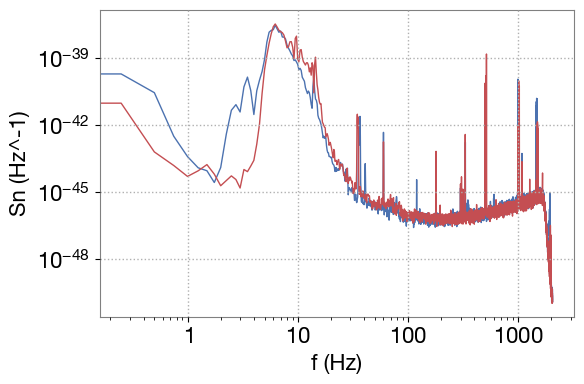

In [213]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_psd, psd_H1, c=colors[0], lw=1)
ax.loglog(freqs_psd, psd_L1, c=colors[1], lw=1)

# ax.set_xlim([5., 2048.])
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'Sn (Hz^-1)')

fig.tight_layout()

In [214]:
# Data selected to be +-4s around the event
# _d for 'data' that we are going to actually use

n = 2**np.round(np.log2(8. / dt))
mask_d = ( -n//2*dt <= times) & (times < n//2*dt)
times_d = times[mask_d]
strain_H1_d = strain_H1[mask_d]
strain_L1_d = strain_L1[mask_d]

n, n*dt, len(times_d), [times_d[0], times_d[-1]]

(np.float64(32768.0),
 np.float64(8.0),
 32768,
 [np.float64(-4.0), np.float64(3.999755859375)])

In [215]:
# Tapering data at both ends
w = window_planck(times_d, times_d[0], times_d[-1], 0.5, 0.5)
strain_H1_tap = w * strain_H1_d
strain_L1_tap = w * strain_L1_d

In [216]:
# Data FD
freq_H1, strain_H1_fd = fft_positivef(times_d, strain_H1_tap)
freq_L1, strain_L1_fd = fft_positivef(times_d, strain_L1_tap)

df = freq_H1[1] - freq_H1[0]
df

np.float64(0.125)

In [217]:
# Frequency range for inner products
mask = (10. < freq_H1) & (freq_H1 < 1024.)
freq = freq_H1[mask]
freq.shape

(8111,)

## Signal model: A exp(i alpha) exp(-2i pi f Deltat) * h2-2(f)

We will reuse the simplified template model of `tutorial_1`: $A$ and $\alpha$ are an effective amplitude and phase encapsulating distance, inclination, phase, polarization, sky position, ...
$$ \tilde{h}_{\rm temp}(f) = A e^{i \alpha} e^{-2 i \pi f \Delta t} \tilde{h}_{2,-2}(f)$$

In [103]:
def PhenomXAS_LAL(freqs, M, q, chi1z, chi2z, dist, f_ref=100., phi_ref=0., Deltat=0.):
    
    Ms = M * lal.MTSUN_SI
    
    m1_SI = M * q/(1.+q) * lal.MSUN_SI
    m2_SI = M * 1./(1.+q) * lal.MSUN_SI
    
    dist_SI = (dist * 1e6 * lal.PC_SI)
    
    lal_params = lal.CreateDict()
    # NOTE: we set this to deactivate multibanding
    # lalsim.SimInspiralWaveformParamsInsertPhenomXHMThresholdMband(lal_params, 0)
    
    # Amplitude prefactor for physical units
#     amp0 = M * lal.MRSUN_SI * M * lal.MTSUN_SI / (dist * 1e6 * lal.PC_SI);

    # Input frequency sequence
    freqsSequence = lal.CreateREAL8Sequence(len(freqs))
    freqsSequence.data[:] = freqs[:]
    
    # Generate
    h22 = lalsimulation.SimIMRPhenomXASFrequencySequence(
        freqsSequence,
        m1_SI,
        m2_SI,
        chi1z,
        chi2z,
        dist_SI,
        phi_ref,
        f_ref,
        lal_params);

    # Extract data
    h2m2data = np.copy(h22.data.data)
    # NOTE: PhenomX FrequencySeries output is for frequencies ]-N/2, N/2] 
    # freq = deltaf * np.arange(-len(h22data)//2 + 1, len(h22data)//2 + 1)
    
    # Convention correction: no conjugation here, LAL convention (factor (-1)^l = 1 here anyway)
    # h22data = np.conj(h22data)
    
    # Add time shift by Deltat
    h2m2data *= np.exp(-2*1j*np.pi*Deltat*freqs)
        
    return freqs, h2m2data

In [104]:
def signal_h(freq, M, q, A, Deltat, alpha):
    m1 = M * q / (1+q)
    m2 = M * 1. / (1+q)
    dist = 1e3
    chi1 = 0.
    chi2 = 0.
    f, h2m2 = PhenomXAS_LAL(freq, M, q, chi1, chi2, dist, Deltat=Deltat)
    h2m2 *= A * np.exp(1j*alpha)
    return f, h2m2

In [110]:
f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

The performance of the likelihood compuation is crucial for sampling, with our settings (8s of data only, low max frequency, very simple waveform) we get a good evaluation speed: 

In [111]:
%timeit f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

2.53 ms ± 76.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


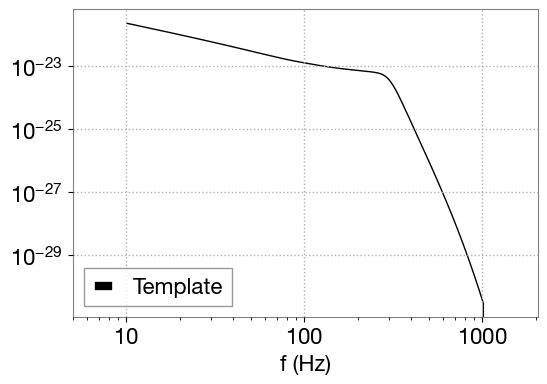

In [112]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(f, np.abs(h), c='k', label=r'Template')

ax.set_xlim(5., 2048.)

ax.set_xlabel(r'f (Hz)')
ax.legend(loc='lower left')

## Setting up data, prior and likelihood

Recall that we the inner product intervening in the matched filter statistic and the likelihood is
$$ ( a | b ) = 4 \mathrm{Re} \int_{0}^{+\infty} df \; \frac{\tilde{a}^{*}(f)\tilde{b}(f)}{S_n(f)}$$
The likelihood is
$$ \ln\mathcal{L}(\theta) = -\frac{1}{2} (d - h(\theta) | d - h(\theta)) $$

The posterior that we want to sample from is
$$ p(\theta | d) \propto p(d | \theta) p(\theta) $$
for the priors, we take them flat for simplicity. Unphysical regions can be implemented by setting the prior there to 0 (in log, some large negative number).

In [218]:
psd_vals = psd_H1_interp(freq)
invpsd_vals = 1./psd_vals

data = strain_H1_fd[mask]

In [219]:
def prior_check(x, prior_bounds):
    if prior_bounds is None:
        return True
    else:
        # NOTE: the following (faster) raises 'list indices must be integers or slices, not tuple'
        # but seems to depend on the version of python/numpy ?
        # return np.all((prior_bounds[:,0] <= x) * (x <= prior_bounds[:,1]))
        return np.all([(prior_bounds[i][0]<=x[i] and x[i]<=prior_bounds[i][1]) for i in range(len(x))])

def lnprior(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        return 0.

In [220]:
def lnlike(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        M, q, A, Deltat, alpha = x
        _, h_vals = signal_h(freq, M, q, A, Deltat, alpha)
        # h_vals = h['amp'] * np.exp(1j * h['phase'])
        resid = h_vals - data
        integrand = np.real(resid * np.conj(resid)) * invpsd_vals
        return -1./2 * 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)

## Sampling with Eryn

We will use the sampler Eryn, an ensemble sampler MCMC with parallel-tempering.

We refer to the documentation of Eryn for more details: [Eryn](https://mikekatz04.github.io/Eryn/html/index.html)

In [221]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds

In [234]:
# Params: M, q, A, Deltat, alpha

list_params = ['M', 'q', 'A', 'Deltat', 'alpha']

prior_range = np.array([
    [65., 75.],
    [1., 2.],
    [0., 2.],
    [-1., 1.],
    [-np.pi, np.pi]])

In [235]:
# set prior limits
ndim = 5
priors_in = {i: uniform_dist(prior_range[i][0], prior_range[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)

In [236]:
np.random.seed(1)

ndim = 5
nwalkers = 32
ntemps = 5
Tmax = 50
nsteps = 1000

# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps, Tmax=Tmax)

# Starting positions
# randomize throughout prior
coords = priors.rvs(size=(ntemps, nwalkers,))

# initialize sampler
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    lnlike,
    priors,
    args=[],
    kwargs={'prior_bounds': prior_range},
    tempering_kwargs=tempering_kwargs
)

In [237]:
# This run should take about 4-5 min
out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=1)

100%|█████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:46<00:00,  3.49it/s]


In [238]:
samples = ensemble.get_chain()['model_0']
log_likelihoods = ensemble.get_log_like()
samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

In [293]:
# Output to file - note that Eryn has proper backends that also allow to resume a run, we do not do that here
np.save('./samples/gw150914_example_eryn_samples.npy', samples)
np.save('./samples/gw150914_example_eryn_log_likelihoods.npy', log_likelihoods)

### Loading results

In [ ]:
# Google colab: fetching results from Google drive and loading them

#!wget -O gw150914_example_eryn_samples.npy --no-check-certificate -r 'https://drive.usercontent.google.com/download?export=download&id=1O9yIURRffKJtcC5cFCW2WBIHPSklctJO&confirm=t'
#!wget -O gw150914_example_eryn_log_likelihoods.npy --no-check-certificate -r 'https://drive.usercontent.google.com/download?export=download&id=1PkihEuYYqTn91Wx8TvFrBOr_8UdV3gnf&confirm=t'

# samples = np.load('gw150914_example_eryn_samples.npy')
# log_likelihoods = np.load('gw150914_example_eryn_log_likelihoods.npy')

In [16]:
samples = np.load('./samples/gw150914_example_eryn_samples.npy')
log_likelihoods = np.load('./samples/gw150914_example_eryn_log_likelihoods.npy')

In [123]:
# Formats:
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim).
# log_likelihoods: (nsteps, ntemps, nwalkers).

nsteps, ntemps, nwalkers, nleaves_max, ndim = samples.shape

samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

### A first look: with the full chains, no burn-in

Here we select the 0-temperature chain and plot the histogram of log-likelihood values, as well as the corner plot in all 5 parameters.

In [239]:
temp = 0

samples_flat_all = np.zeros(((nsteps) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat_all[:,i] = np.ravel(samples[:,temp,:,0,i], order='F')
lnlike_flat_all = np.ravel(log_likelihoods[:,temp,:], order='F')

In [244]:
lnL_max = np.max(lnlike_flat_all)
imax = np.argmax(lnlike_flat_all)
x_max = samples_flat_all[imax, :]
x_max, lnL_max

(array([72.41354987,  1.06043612,  0.3673211 ,  0.42352379,
        -0.66426932]),
 np.float64(-13631.39209526365))

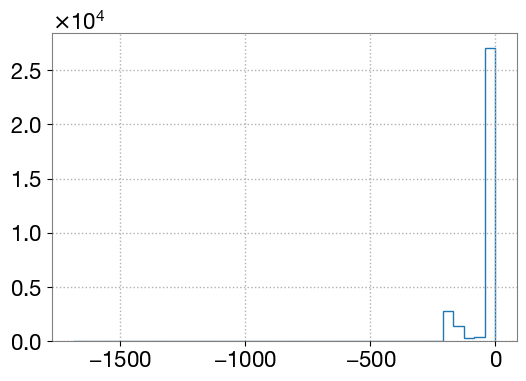

In [240]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_flat_all - np.max(lnlike_flat_all), histtype='step', bins=40);

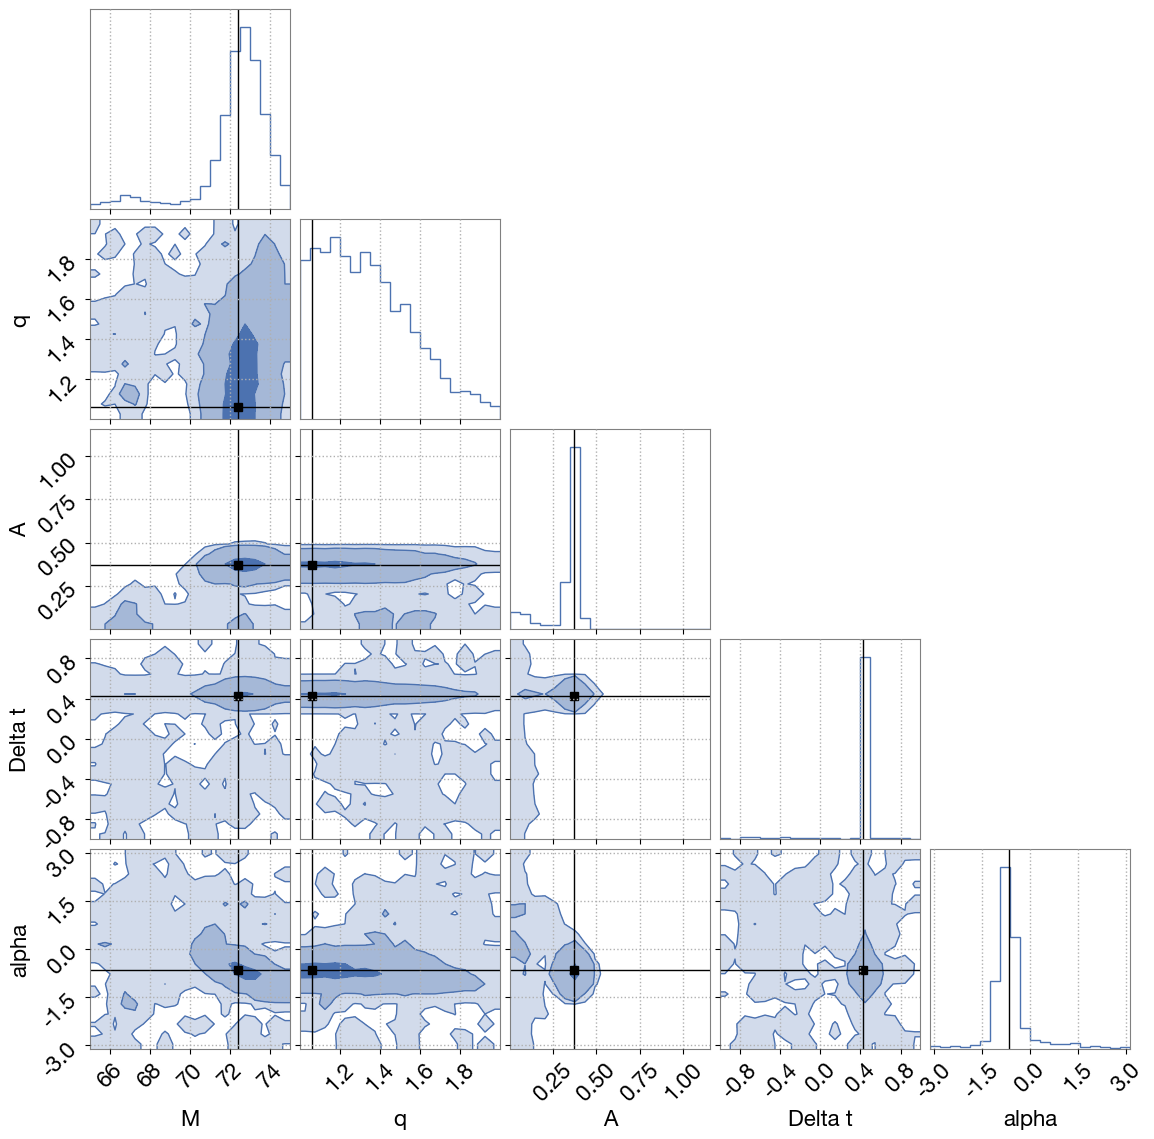

In [245]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(samples_flat_all, plot_density=False, plot_datapoints=False, levels=levels, truths=x_max, truth_color='k', smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

### Visualizing chains

We can visualize what the chains are doing, for every individual walker.
- Plot the trace of log-likelihood values for each walker as a function of the iteration number -- it is better to plot the difference from `lnL_max + 1`, in log scale after flipping the sign
- Plot the trace of the chain values in each of the parameters, as a function of the iteration number
- Which parameter is the harder to find (with our choice of prior ranges) ?
- Explanation of the behaviour of the chains in $A$ ?

In [205]:
# Formats (nleaves_max=1, ignore):
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim).
# log_likelihoods: (nsteps, ntemps, nwalkers).

### Results after burn-in

We need to eliminate the initial part of the chains that correspond to a burn-in phase, where the samples are not representative of the final distribution. We will not get into the arcane of convergence diagnostics here -- we will simply cut the chains by eye.
- decide of a value of `burn`
- redo the histogram of the log-likelihood values for the cut chains
- redo the corner plot for the samples from the cut chains

In [129]:
# burn = ...

# temp = 0

# samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
# for i in range(ndim):
#     samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
# lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

## Waveform for max likelihood

Here we simply repeat the conditioning steps of `tutorial_1.ipynb` inorder to visualize the whitened-band passed max-liklihood template against data.

In [253]:
# Data whitened after band-passing

f_d = freq_H1
w_bp = window_planck(f_d, 10., 512., 10., 64.)

strain_H1_fd_wbp = w_bp * np.sqrt(2*df / psd_H1_interp(f_d)) * strain_H1_fd
strain_L1_fd_wbp = w_bp * np.sqrt(2*df / psd_L1_interp(f_d)) * strain_L1_fd

_, strain_H1_td_wbp = ifft_positivef(f_d, strain_H1_fd_wbp, real=True, tstart=times_d[0])
_, strain_L1_td_wbp = ifft_positivef(f_d, strain_L1_fd_wbp, real=True, tstart=times_d[0])

In [254]:
M_max, q_max, A_max, Deltat_max, alpha_max = x_max
x_max

array([72.60864068,  1.08670073,  0.36226731,  0.42352698,
       -0.68350411])

In [255]:
f_max, h_max = signal_h(freq, M_max, q_max, A_max, Deltat_max, alpha_max)

In [256]:
mask_h = (freq[0] <= f_d) & (f_d <= freq[-1])

def htemplate_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    return ifft_positivef(f_d, h_fd, real=True, tstart=times_d[0])
    
def htemplate_wbp_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    h_wbp_fd =  np.sqrt((2 * df) / psd_H1_interp(f_d)) * h_fd 
    return ifft_positivef(f_d, h_wbp_fd, real=True, tstart=times_d[0])

In [257]:
t_max, h_max_td = htemplate_td(M_max, q_max, A_max, Deltat_max, alpha_max)
t_max, h_max_wbp = htemplate_wbp_td(M_max, q_max, A_max, Deltat_max, alpha_max)

Text(0.5, 0, 't (s)')

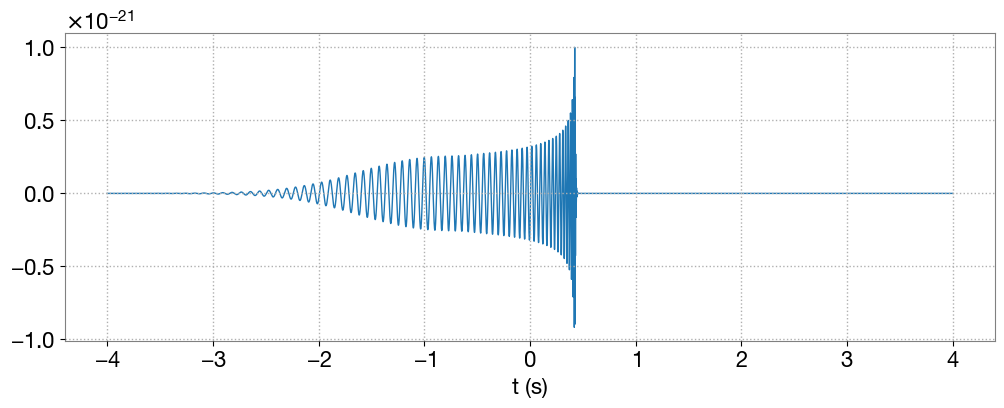

In [258]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(t_max, h_max_td)
ax.set_xlabel(r't (s)')

Text(0.5, 0, 't (s)')

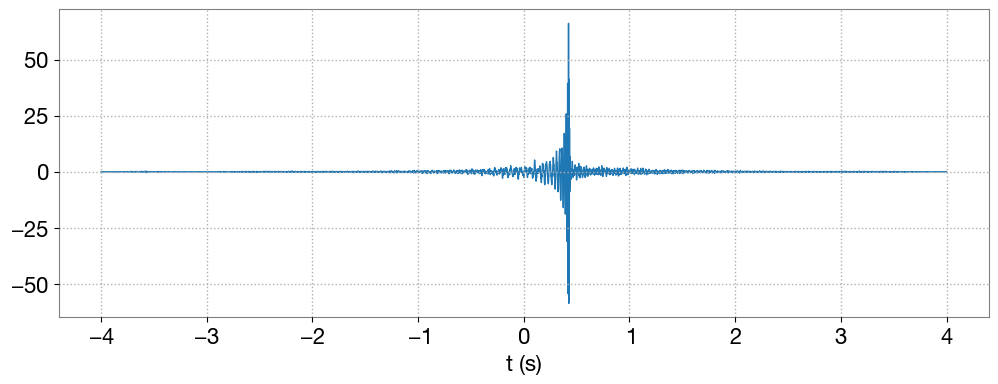

In [259]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(t_max, h_max_wbp)
ax.set_xlabel(r't (s)')

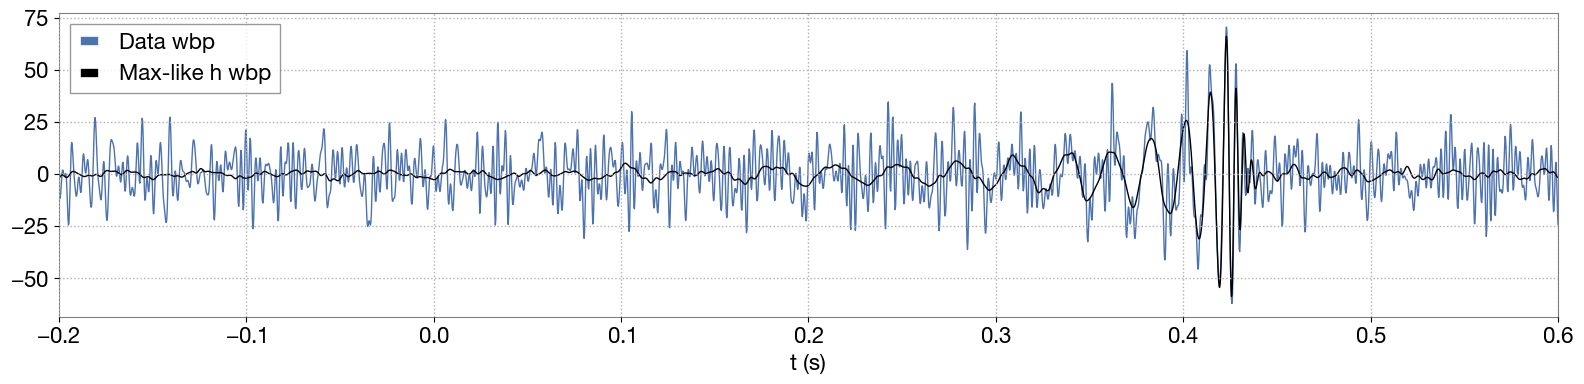

In [261]:
# WARNING: change plotting range if using data on file rather than online

fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(times_d, strain_H1_td_wbp, c=colors[0], label=r'Data wbp')
ax.plot(times_d, h_max_wbp, c='k', label=r'Max-like h wbp')

ax.set_xlim([-0.2, 0.6])
ax.set_xlabel(r't (s)')
ax.legend(loc='upper left')

fig.tight_layout()

Here we visualize the whitened-band wavforms for each template in our posteriors, represented as a confidence interval at each time (we would also have plotted multiple lines, one per samples). This would be the predictive posterior for the waveform itself.

In [262]:
n_rand = 1000
inds = np.random.choice(range(len(samples_flat)), size=n_rand, replace=False)

h_wbp_td_all = np.zeros((len(times_d), n_rand), dtype=float)
for i in tqdm(range(n_rand)):
    M, q, A, Deltat, alpha = samples_flat[inds[i]]
    _, h_wbp_td_vals = htemplate_wbp_td(M, q, A, Deltat, alpha)
    h_wbp_td_all[:,i] = h_wbp_td_vals

100%|████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:05<00:00, 193.90it/s]


In [263]:
qs = np.array([0.025, 0.16, 0.5, 0.84, 0.975])

h_wbp_td_quantiles = np.quantile(h_wbp_td_all, qs, axis=1)
h_wbp_td_quantiles.shape

(5, 32768)

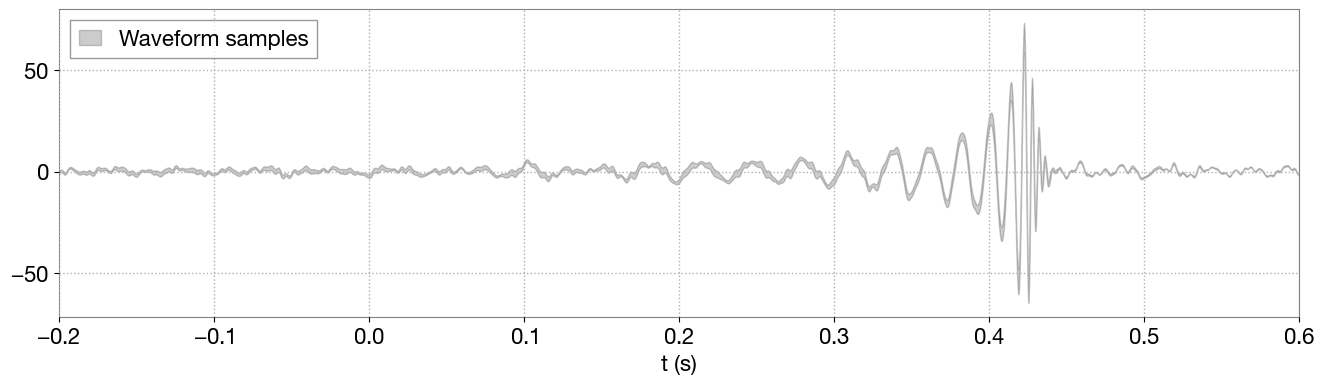

In [264]:
# NOTE: 2sigma waveform reconstruction is very narrow
# WARNING: change plotting range if using data on file rather than online
trange = [-0.2, 0.6]

fig, ax = plt.subplots(1,1, figsize=[16,4])
# ax.plot(times_d, strain_H1_td_wbp, c=colors[0])
# ax.plot(times_d, hmax_wbp, c='k')
ax.fill_between(times_d, h_wbp_td_quantiles[0], h_wbp_td_quantiles[4], color=['k'], alpha=0.2, label='Waveform samples')

ax.set_xlim(trange)
ax.set_xlabel(r't (s)')
ax.legend(loc='upper left')

# Part III: simplified parameter estimation

## Visualizing the likelihood

In [265]:
list_params = ['M', 'q', 'A', 'Deltat', 'alpha']
npt = 400
lnlike_vals = {}
param_vals = {}

In [266]:
param = 'M'
width = 10.

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 349.76it/s]


In [267]:
param = 'q'

i_param = list_params.index(param)
param_vals[param] = np.linspace(1., 2., npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 356.24it/s]


In [268]:
param = 'A'
width = 0.5

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 345.72it/s]


In [269]:
param = 'Deltat'
width = 0.05

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 352.62it/s]


In [270]:
param = 'alpha'
width = 2.

i_param = list_params.index(param)
param_vals[param] = x_max[i_param] + np.linspace(-width, width, npt)

lnlike_vals[param] = np.zeros(npt, dtype=float)
for i in tqdm(range(npt)):
    x = x_max.copy()
    x[i_param] = param_vals[param][i]
    lnlike_vals[param][i] = lnlike(x)

100%|██████████████████████████████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 334.75it/s]


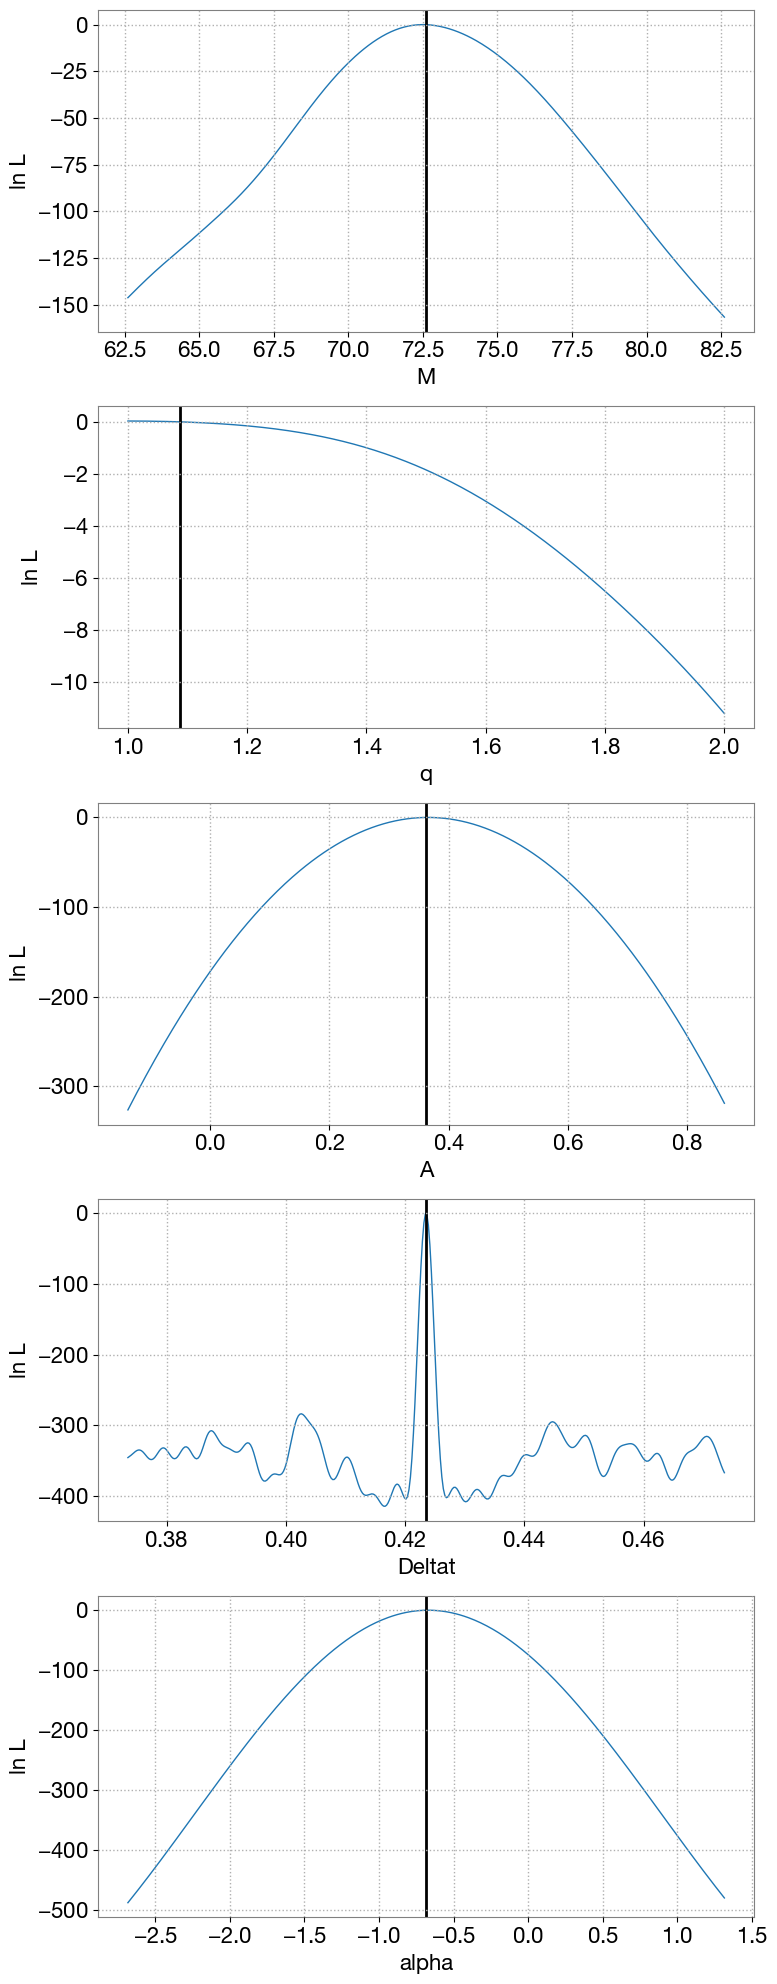

In [271]:
fig, axs = plt.subplots(5,1, figsize=[8,20])
for ip,param in enumerate(list_params):
    axs[ip].plot(param_vals[param], lnlike_vals[param] - lnL_max)
    axs[ip].axvline(x_max[ip], c='k', lw=2.)
    axs[ip].set_xlabel(r'' + param)
    axs[ip].set_ylabel(r'ln L')
fig.tight_layout()

## Building a Fisher matrix

Recall that we the inner product intervening in the matched filter statistic and the likelihood is
$$ ( a | b ) = 4 \mathrm{Re} \int_{0}^{+\infty} df \; \frac{\tilde{a}^{*}(f)\tilde{b}(f)}{S_n(f)}$$

The likelihood in zero noise with a true signal $h_0$ is $\ln \mathcal{L} = - (h_0 -h |h_0 -h)/2$, becomes at leading order in parameter deviations $\Delta \theta^i$:
$$ \ln \mathcal{L}(\theta) = -\frac{1}{2} \Delta \theta^{j} \Delta \theta^{k} (\partial_{j} h | \partial_{k} h) + \mathcal{O} (\Delta \theta^{3})$$
This corresponds to a Gaussian approximation of the likelihood near its peak, and we can estimate the covariance as the inverse $\Gamma^{-1}$ of the Fisher matrix:
$$ \Gamma_{jk} = (\partial_{j} h | \partial_{k} h)$$
Waveform derivatives can be computed numerically by finite differences: (althoug some derivatives are analytical here, like $A$ and $\alpha$)
$$ \partial_{\theta^i} h = \frac{h(\theta^i + \varepsilon^i) - h(\theta^i - \varepsilon^i)}{2\varepsilon} $$
(abuse of notation, the other parameters are kept fixed). The steps $\varepsilon^i$ must be chosen within a certain range to achieve numerical stability of the derivative for each parameter.

In [272]:
list_params = ['M', 'q', 'A', 'Deltat', 'alpha']

def signal_dh(param, step, freq, M, q, A, Deltat, alpha):
    params = np.array([M, q, A, Deltat, alpha])
    params_plus = params.copy()
    params_minus = params.copy()
    i_param = list_params.index(param)
    params_plus[i_param] += step
    params_minus[i_param] -= step
    f, h2m2_plus = signal_h(freq, *params_plus)
    f, h2m2_minus = signal_h(freq, *params_minus)
    return f, (h2m2_plus - h2m2_minus) / (2*step)

def fisher(freq, M, q, A, Deltat, alpha, steps, list_params=list_params, return_cov=True):
    n_params = len(list_params)
    dh = {}
    for param in list_params:
        _, dh[param] = signal_dh(param, steps[param], freq, M, q, A, Deltat, alpha)
    fisher_matrix = np.empty((n_params, n_params), dtype=float)
    for i in range(n_params):
        for j in range(n_params):
            integrand = np.real(dh[list_params[i]] * np.conj(dh[list_params[j]])) * invpsd_vals
            fisher_matrix[i,j] = 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)
    fisher_cov = None
    if return_cov:
        fisher_cov = np.linalg.inv(fisher_matrix)
    return fisher_matrix, fisher_cov

## Checking the steps for numerical derivatives

The steps $\varepsilon^i$ for the numerical derivatives must be chosen within a certain range to achieve numerical stability of the derivative for each parameter.
- for each parameter, compute just the diagonal element $\Gamma_{jj} = (\partial_j h | \partial_j h)$ for the parameter $\theta^j$, for a wide range (in log) of possible values for the small step
- look for an extended plateau where it looks like the result are stable
- choose an $\varepsilon^j$ within that plateau

## Comparing the Fisher and Bayesian results 

We want now to compare the Fisher result for the covariance to the posterior samples. The Fisher will be computed at the max-likelihood point (we don't have and never will have the true parameters !)
- compute our reference $\Gamma_{jk}$ at $\theta_{\rm max}$ for the max-likelihood
- draw 'samples' from that covariance using `np.random.multivariate_normal`, reject the ones with $q<1$ (a cheap way of enforcing our priors)
- compare to our posterior samples in a corner plot

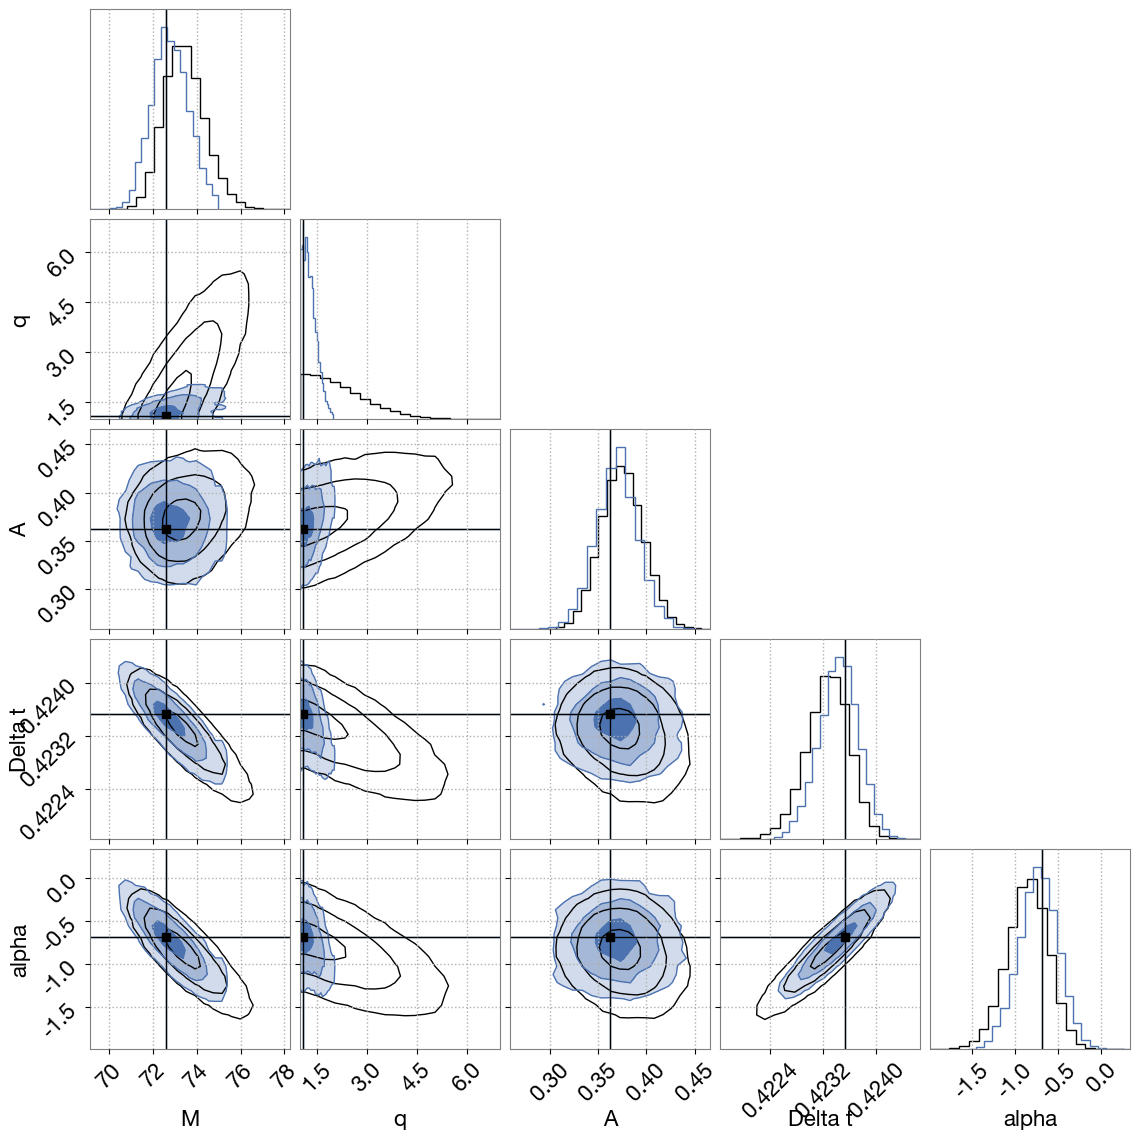

In [283]:
# Plotting syntax for multiple corners:
# fig = corner.corner(samples_1, ...)
# corner.corner(samples_2, fig=fig, ...)